# RIM Experiment Analysis

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rim_teleop.data import ExperimentRegistry, load_streams

DATA_DIR = "/home/athena/csirois/data/franka/rim"

registry = ExperimentRegistry(DATA_DIR)

# --- Select run ---
# run = registry.latest()                         # most recent
run = registry.get("run_20260526_142318")     # specific run

print(f"Run: {run.name}  ({run.created_at})")
cfg_iface = run.config["interface"]
print(f"rim_enabled={cfg_iface['rim_enabled']}  "
      f"force_feedback={cfg_iface['force_feedback']}  "
      f"K={cfg_iface['stiffness']}  D={cfg_iface['damping']}  "
      f"contact_surface={cfg_iface['contact_surface']}")

Run: run_20260526_142318  (2026-05-26 14:23:18.766926)
rim_enabled=True  force_feedback=rim  K=1000.0  D=90.0  contact_surface=0.03


In [95]:
streams = load_streams(run)
print("Streams loaded:")
for name, df in streams.items():
    print(f"  {name}: {len(df)} rows | {list(df.columns)}")

# Normalise all timestamps to a shared t=0
t0 = min(df["ts"].min() for df in streams.values())
for df in streams.values():
    df["t"] = df["ts"] - t0

T_MAX = max(df["t"].max() for df in streams.values())
print(f"\nTotal duration: {T_MAX:.1f} s")

Streams loaded:
  haptic: 101029 rows | ['ts', 'leader_pos', 'leader_vel', 'leader_vel_filt', 'force_cmd', 'rim_interface_force', 'robot_force', 'deadman_active']
  control: 5052 rows | ['ts', 'rim_x', 'interface_force', 'model_stamp_s']
  rim_model: 5052 rows | ['ts', 'M_eff', 'z_i', 'f_eff', 'x', 'v']
  tracking: 5052 rows | ['ts', 'tcp', 'tool_tip', 'rim', 'target']
  metrics: 21 rows | ['ts', 'haptic.measured_hz', 'haptic.target_hz', 'haptic.mean_dt_ms', 'haptic.p95_dt_ms', 'haptic.max_dt_ms', 'rim.measured_hz', 'rim.target_hz', 'rim.mean_dt_ms', 'rim.p95_dt_ms', 'rim.max_dt_ms', 'control.measured_hz', 'control.target_hz', 'control.mean_dt_ms', 'control.p95_dt_ms', 'control.max_dt_ms']
  rim: 101025 rows | ['ts', 'x_rim', 'v_rim', 'interface_force']

Total duration: 101.0 s


---
## Overview — full recording

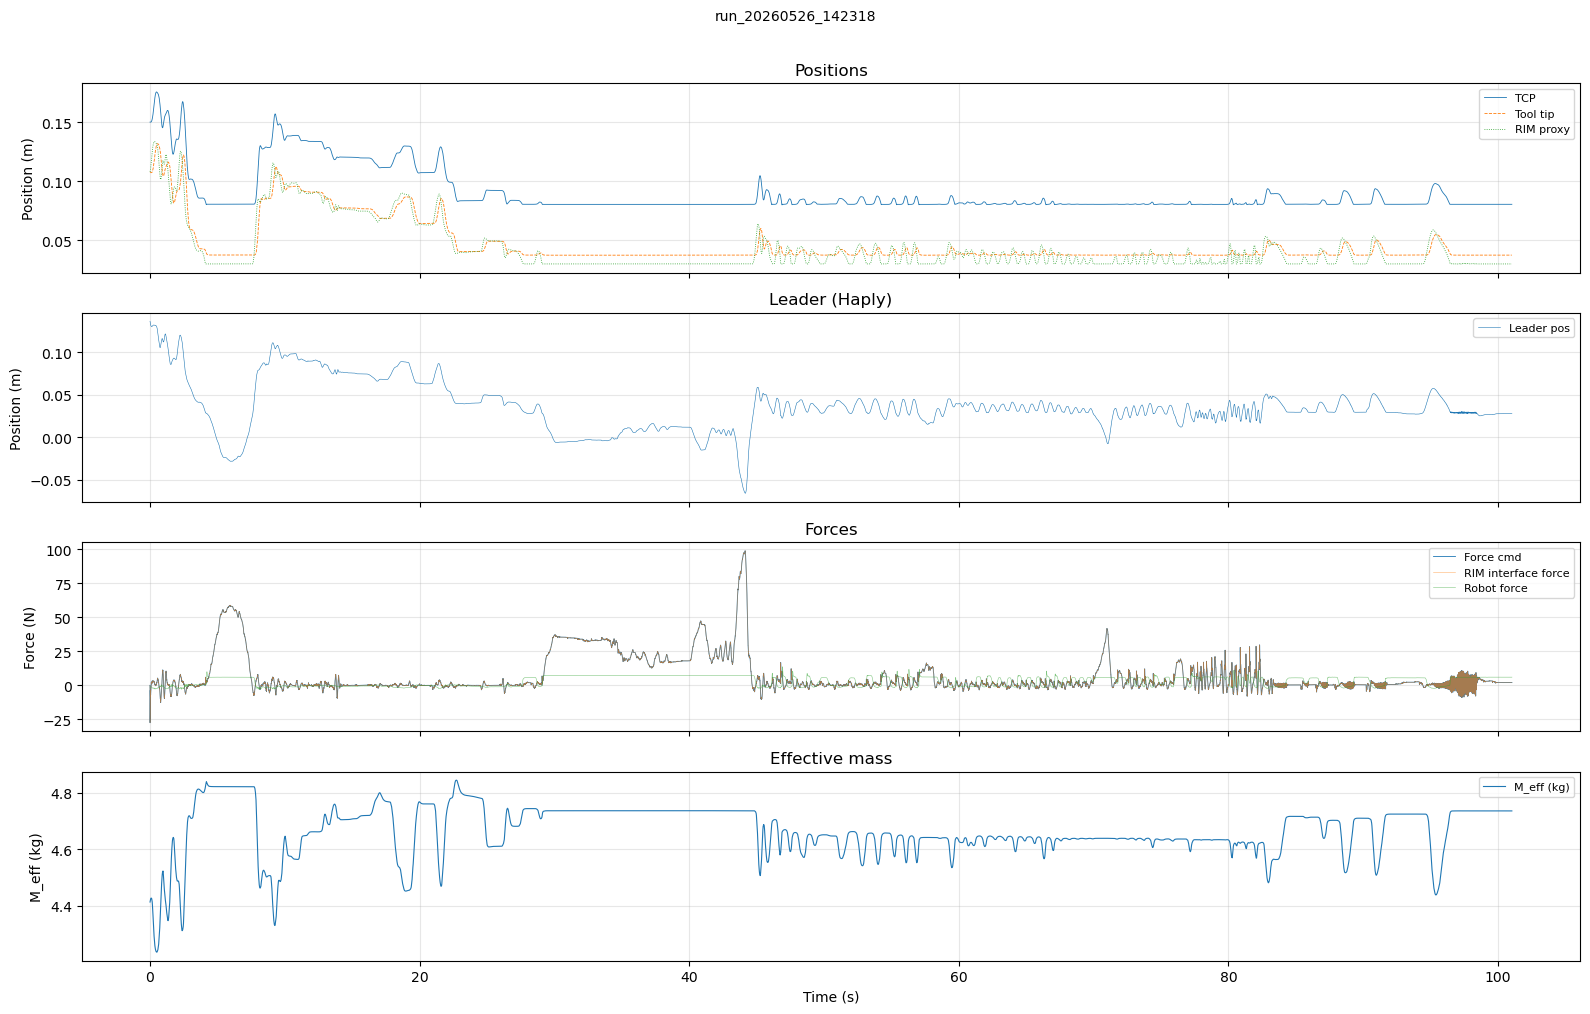

In [96]:
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# — Positions
ax = axes[0]
if "tracking" in streams:
    tr = streams["tracking"]
    ax.plot(tr["t"], tr["tcp"],      lw=0.6, label="TCP")
    ax.plot(tr["t"], tr["tool_tip"], lw=0.6, ls="--", label="Tool tip")
    ax.plot(tr["t"], tr["rim"],      lw=0.6, ls=":",  label="RIM proxy")
ax.set(ylabel="Position (m)", title="Positions")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Haptic leader position
ax = axes[1]
if "haptic" in streams:
    hap = streams["haptic"]
    ax.plot(hap["t"], hap["leader_pos"], lw=0.4, label="Leader pos")
ax.set(ylabel="Position (m)", title="Leader (Haply)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Forces
ax = axes[2]
if "haptic" in streams:
    ax.plot(hap["t"], hap["force_cmd"],          lw=0.6, label="Force cmd")
    if "rim_interface_force" in hap.columns:
        ax.plot(hap["t"], hap["rim_interface_force"], lw=0.4, alpha=0.6, label="RIM interface force")
    if "robot_force" in hap.columns:
        ax.plot(hap["t"], hap["robot_force"],         lw=0.4, alpha=0.6, label="Robot force")
ax.set(ylabel="Force (N)", title="Forces")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — RIM model
ax = axes[3]
if "rim_model" in streams:
    rm = streams["rim_model"]
    ax.plot(rm["t"], rm["M_eff"], lw=0.8, label="M_eff (kg)")
ax.set(xlabel="Time (s)", ylabel="M_eff (kg)", title="Effective mass")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle(run.name, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

---
## Time range selection

Set `T_START` and `T_END` (seconds, normalised) to zoom into a region of interest.
Set either to `None` to keep the full extent.

In [105]:
T_START = 94   # 116
T_END   = 100   # 119

def clip(df: pd.DataFrame, t_start=T_START, t_end=T_END) -> pd.DataFrame:
    """Return rows within [t_start, t_end] (inclusive, None = unbounded)."""
    mask = pd.Series(True, index=df.index)
    if t_start is not None:
        mask &= df["t"] >= t_start
    if t_end is not None:
        mask &= df["t"] <= t_end
    return df[mask]

---
## Zoomed — position tracking

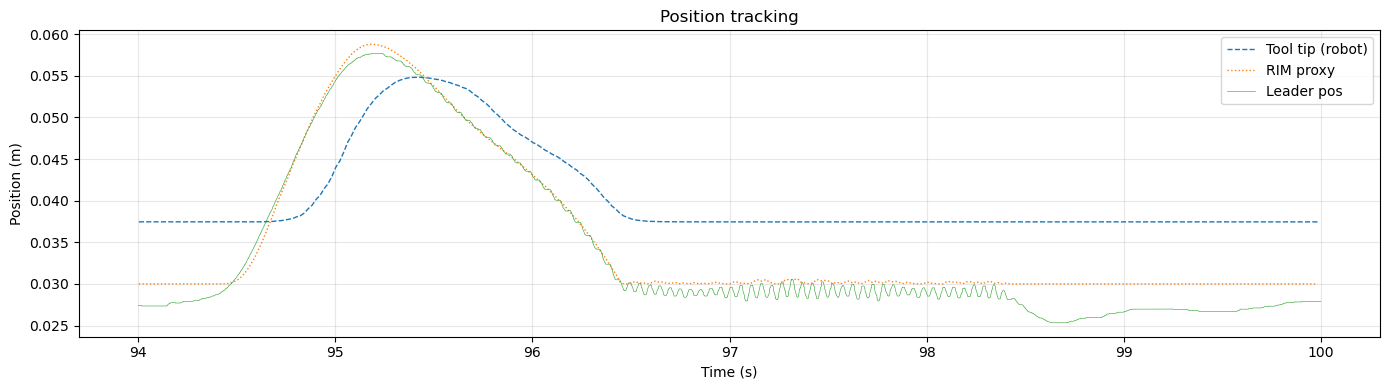

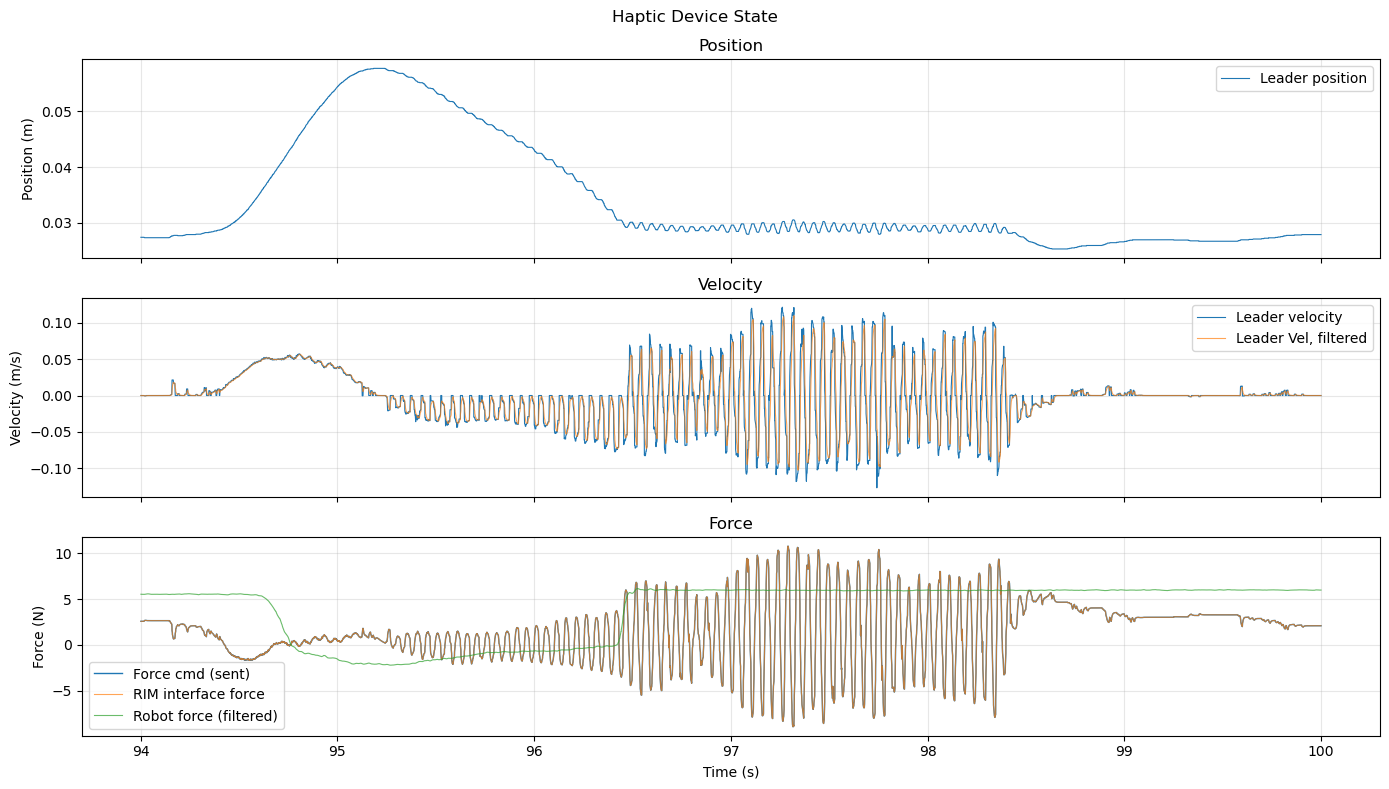

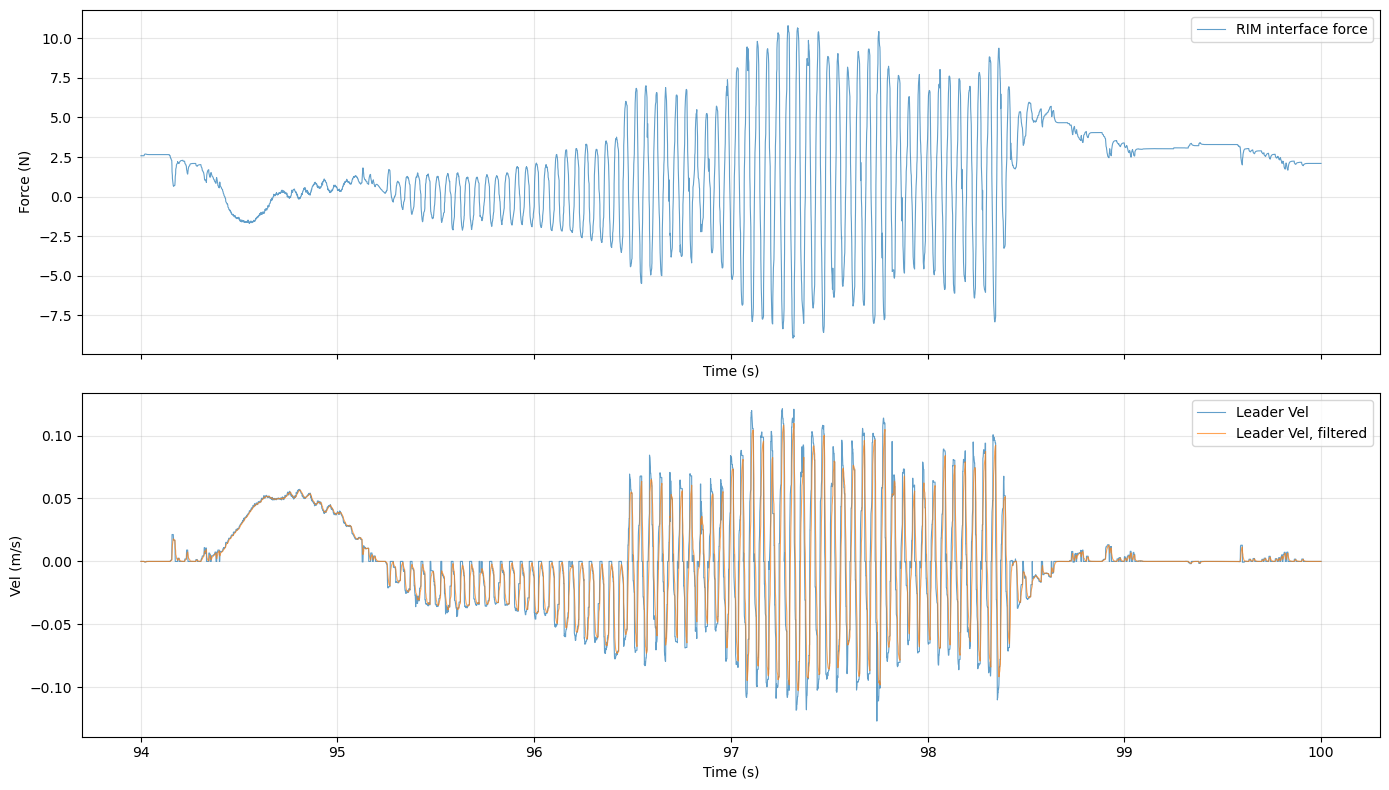

In [106]:
# --- Positions
if "tracking" in streams:
    tr = clip(streams["tracking"])
    fig, ax = plt.subplots(figsize=(14, 4))
    # ax.plot(tr["t"], tr["tcp"],      lw=1.0, label="TCP (robot EE)")
    ax.plot(tr["t"], tr["tool_tip"], lw=1.0, ls="--", label="Tool tip (robot)")
    ax.plot(tr["t"], tr["rim"],      lw=1.0, ls=":",  label="RIM proxy")
    ax.plot(hap["t"], hap["leader_pos"], lw=0.4, label="Leader pos")
    # ax.plot(tr["t"], tr["target"],   lw=0.8, alpha=0.6, label="Sent target (TCP)")
    ax.set(xlabel="Time (s)", ylabel="Position (m)", title="Position tracking")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- Haptic Device State
if "haptic" in streams:
    hap = clip(streams["haptic"])
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    # Position
    axes[0].plot(hap["t"], hap["leader_pos"], lw=0.8, label="Leader position")
    axes[0].set(ylabel="Position (m)", title="Position")
    axes[0].legend()

    # Velocity
    axes[1].plot(hap["t"], hap["leader_vel"], lw=0.8, label="Leader velocity")
    axes[1].plot(hap["t"], hap["leader_vel_filt"], lw=0.8, alpha=0.7, label="Leader Vel, filtered")
    axes[1].set(ylabel="Velocity (m/s)", title="Velocity")
    axes[1].legend()


    axes[2].plot(hap["t"], hap["force_cmd"],          lw=1.0, label="Force cmd (sent)")
    axes[2].plot(hap["t"], hap["rim_interface_force"], lw=0.8, alpha=0.7, label="RIM interface force")
    axes[2].plot(hap["t"], hap["robot_force"],         lw=0.8, alpha=0.7, label="Robot force (filtered)")
    axes[2].set(xlabel="Time (s)", ylabel="Force (N)", title="Force")
    axes[2].legend()


    for ax in axes:
        ax.grid(True, alpha=0.3)
    
    plt.suptitle("Haptic Device State")
    plt.tight_layout()
    plt.show()


hap_zoom = clip(streams["haptic"], T_START, T_END)

# --- Interface Force
if "haptic" in streams:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(hap_zoom["t"], hap_zoom["rim_interface_force"], lw=0.8, alpha=0.7, label="RIM interface force")
    axes[0].set(xlabel="Time (s)", ylabel="Force (N)")
    axes[0].legend()

    axes[1].plot(hap_zoom["t"], hap_zoom["leader_vel"], lw=0.8, alpha=0.7, label="Leader Vel")
    axes[1].plot(hap_zoom["t"], hap_zoom["leader_vel_filt"], lw=0.8, alpha=0.7, label="Leader Vel, filtered")

    axes[1].set(xlabel="Time (s)", ylabel="Vel (m/s)")
    axes[1].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Zoomed — RIM model parameters

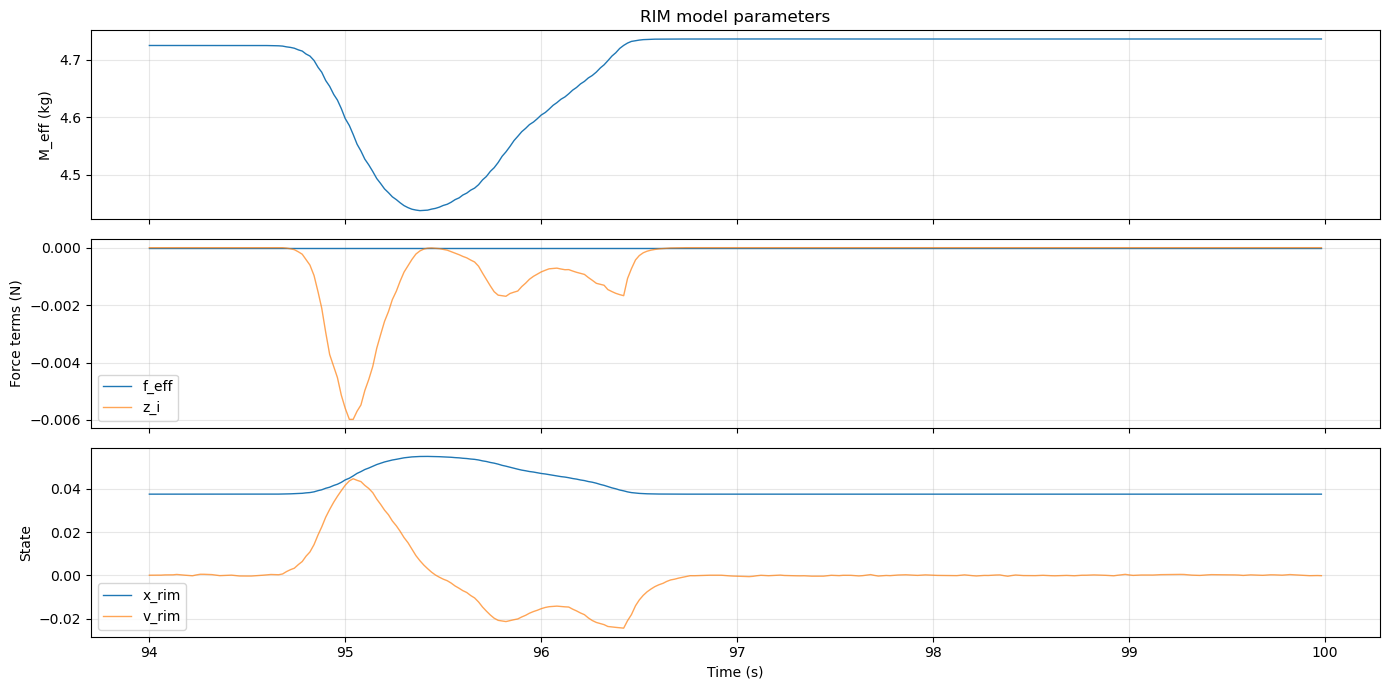

In [102]:
if "rim_model" in streams:
    rm = clip(streams["rim_model"])
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(rm["t"], rm["M_eff"], lw=1.0)
    axes[0].set(ylabel="M_eff (kg)", title="RIM model parameters")

    axes[1].plot(rm["t"], rm["f_eff"], lw=1.0, label="f_eff")
    axes[1].plot(rm["t"], rm["z_i"],   lw=1.0, label="z_i", alpha=0.7)
    axes[1].set(ylabel="Force terms (N)")
    axes[1].legend()

    axes[2].plot(rm["t"], rm["x"], lw=1.0, label="x_rim")
    axes[2].plot(rm["t"], rm["v"], lw=1.0, label="v_rim", alpha=0.7)
    axes[2].set(xlabel="Time (s)", ylabel="State")
    axes[2].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Force spectrum — instability diagnosis

FFT of the haptic force command over the selected time window to identify oscillation frequencies.

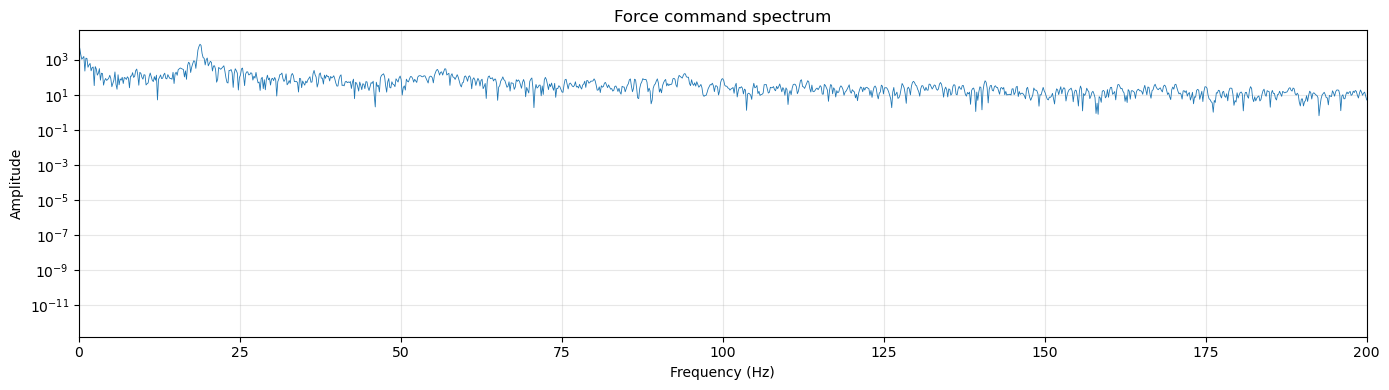

Measured haptic rate: 966 Hz
Top 5 spectral peaks: [18.8 19.  18.7  0.2 18.5] Hz


In [103]:
if "haptic" in streams:
    hap = clip(streams["haptic"])
    force = hap["force_cmd"].values
    ts = hap["ts"].values
    dt_median = float(np.median(np.diff(ts)))
    fs = 1.0 / dt_median

    freqs = np.fft.rfftfreq(len(force), d=dt_median)
    spectrum = np.abs(np.fft.rfft(force - force.mean()))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.semilogy(freqs, spectrum, lw=0.6)
    ax.set(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Force command spectrum")
    ax.set_xlim(0, min(fs / 2, 200))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    top_freqs = freqs[np.argsort(spectrum)[-5:][::-1]]
    print(f"Measured haptic rate: {fs:.0f} Hz")
    print(f"Top 5 spectral peaks: {top_freqs.round(1)} Hz")

## Loop rate metrics

In [104]:
if "metrics" in streams:
    met = streams["metrics"]
    print("Loop rate summary (last snapshot):")
    last = met.iloc[-1]
    for loop in ["haptic", "rim", "control"]:
        hz_col = f"{loop}.measured_hz"
        p95_col = f"{loop}.p95_dt_ms"
        if hz_col in last:
            print(f"  {loop:8s}: {last[hz_col]:.1f} Hz  p95={last[p95_col]:.2f} ms")

Loop rate summary (last snapshot):
  haptic  : 1000.0 Hz  p95=1.96 ms
  rim     : 1000.8 Hz  p95=2.04 ms
  control : 50.0 Hz  p95=20.97 ms
